C:\Users\Welcome\AppData\Local\Temp\ipykernel_2944\1503837571.py:31: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True) # Handling missing values if any


Data Types Check:
 OrderID               int64
OrderDate    datetime64[ns]
Product              object
Category             object
Region               object
Quantity              int64
Price                 int64
dtype: object

Total Revenue: 4847

Sales by Region:
 Region
East      365
North    3230
South     820
West      432
Name: TotalSales, dtype: int64


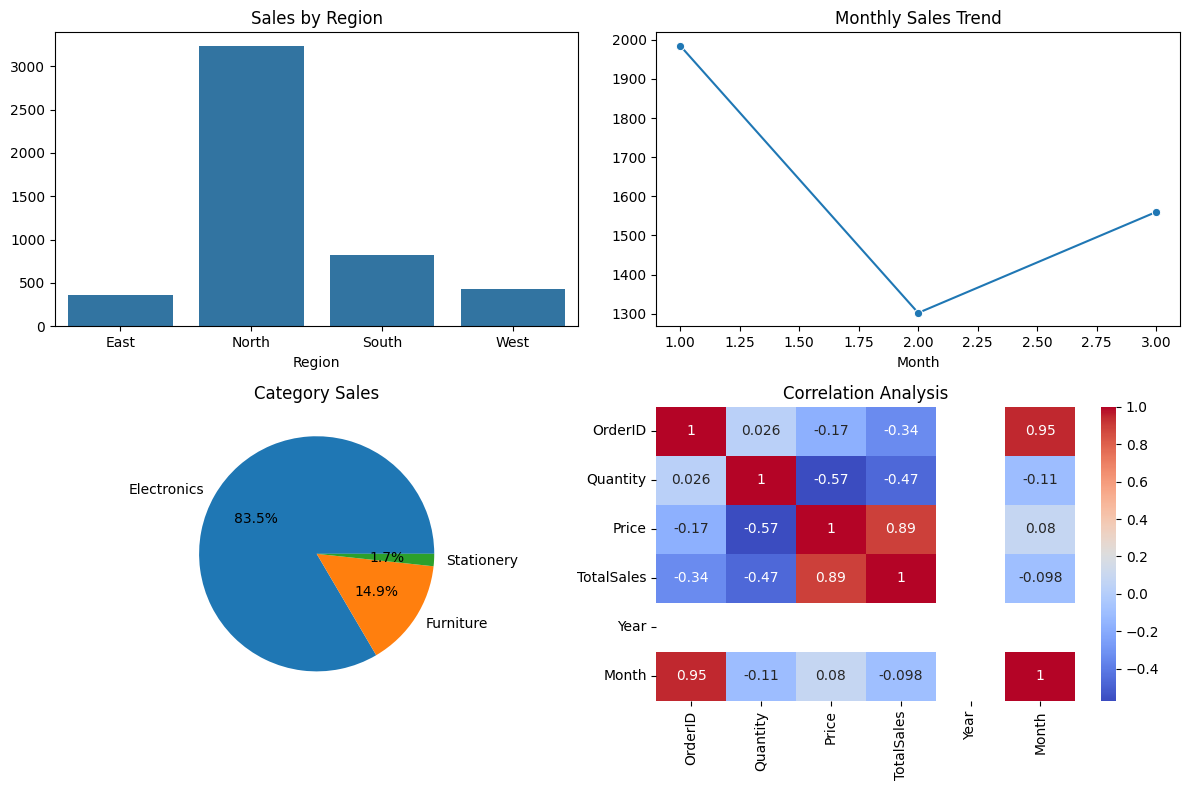


--- Sales Prediction ---
Predicted Sales: 95.00
Predicted Sales: 287.00
Predicted Sales: 760.00


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# 1. Data Loading (Using data from screenshot)
data = {
    'OrderID': [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012],
    'OrderDate': ['2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08', '2024-02-01', 
                  '2024-02-02', '2024-02-10', '2024-02-15', '2024-03-03', '2024-03-10', 
                  '2024-03-15', '2024-03-20'],
    'Product': ['Laptop', 'Mouse', 'Desk Chair', 'Keyboard', 'Laptop', 'Monitor', 
                'Notebook', 'Pen Pack', 'Laptop', 'Desk Chair', 'Keyboard', 'Table'],
    'Category': ['Electronics', 'Electronics', 'Furniture', 'Electronics', 'Electronics', 
                 'Electronics', 'Stationery', 'Stationery', 'Electronics', 'Furniture', 
                 'Electronics', 'Furniture'],
    'Region': ['North', 'South', 'West', 'East', 'North', 'South', 'East', 'West', 
               'North', 'South', 'East', 'West'],
    'Quantity': [2, 5, 1, 3, 1, 2, 10, 8, 1, 2, 4, 1],
    'Price': [800, 20, 150, 45, 820, 200, 5, 4, 810, 160, 45, 250]
}

df = pd.DataFrame(data)
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# --- Task 2: Data Cleaning ---
df.drop_duplicates(inplace=True)
df.fillna(method='ffill', inplace=True) # Handling missing values if any
print("Data Types Check:\n", df.dtypes)

# --- Task 3: Feature Engineering ---
df["TotalSales"] = df["Quantity"] * df["Price"]
df["Year"] = df["OrderDate"].dt.year
df["Month"] = df["OrderDate"].dt.month

# --- Task 4: Exploratory Data Analysis (EDA) ---
total_revenue = df["TotalSales"].sum()
sales_by_region = df.groupby("Region")["TotalSales"].sum()
sales_by_category = df.groupby("Category")["TotalSales"].sum()
monthly_revenue = df.groupby("Month")["TotalSales"].sum()

print(f"\nTotal Revenue: {total_revenue}")
print("\nSales by Region:\n", sales_by_region)

# --- Task 5: Data Visualization ---
plt.figure(figsize=(12, 8))

# Bar Chart - Sales by Region
plt.subplot(2, 2, 1)
sns.barplot(x=sales_by_region.index, y=sales_by_region.values)
plt.title("Sales by Region")

# Line Chart - Monthly Sales Trend
plt.subplot(2, 2, 2)
sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, marker='o')
plt.title("Monthly Sales Trend")

# Pie Chart - Category Sales
plt.subplot(2, 2, 3)
plt.pie(sales_by_category, labels=sales_by_category.index, autopct='%1.1f%%')
plt.title("Category Sales")

# Heatmap - Correlation
plt.subplot(2, 2, 4)
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Analysis")

plt.tight_layout()
plt.show()

# --- Task 6: Sales Forecasting (Machine Learning) ---
# Preparing data for ML
# Encoding categorical data for the model
df_ml = pd.get_dummies(df, columns=['Region', 'Category'])
X = df_ml[['Month', 'Quantity', 'Price'] + [col for col in df_ml.columns if 'Region_' in col or 'Category_' in col]]
y = df_ml['TotalSales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Example Prediction for upcoming months (Simplified)
print("\n--- Sales Prediction ---")
predictions = model.predict(X_test)
for i, pred in enumerate(predictions):
    print(f"Predicted Sales: {pred:.2f}")